In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay


2026-02-06 18:22:24.024957: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
import pandas as pd
import re
from sklearn.preprocessing import LabelEncoder

# 1. Load the dataset
df = pd.read_csv('cellula toxic data (1).csv')

# 2. Define a text cleaning function
def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    # Lowercase text
    text = text.lower()
    # Remove special characters but keep spaces and basic punctuation
    text = re.sub(r'[^a-zA-Z0-9\s.,!?]', '', text)
    # Remove extra whitespace
    text = " ".join(text.split())
    return text

# 3. Apply cleaning to text columns
df['query_cleaned'] = df['query'].apply(preprocess_text) 
df['image_descriptions_cleaned'] = df['image descriptions'].apply(preprocess_text)

# 4. Encode the Toxic Category target variable
le = LabelEncoder()
df['toxic_category_encoded'] = le.fit_transform(df['Toxic Category'])

# 5. Display the label mapping
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Label Mapping:", mapping)

Label Mapping: {'Child Sexual Exploitation': np.int64(0), 'Elections': np.int64(1), 'Non-Violent Crimes': np.int64(2), 'Safe': np.int64(3), 'Sex-Related Crimes': np.int64(4), 'Suicide & Self-Harm': np.int64(5), 'Unknown S-Type': np.int64(6), 'Violent Crimes': np.int64(7), 'unsafe': np.int64(8)}


In [ ]:
import pandas as pd
from sklearn.utils import resample

# 1️⃣ Compute the average class size (rounded to integer)
class_counts = df['toxic_category_encoded'].value_counts()
avg_count = int(class_counts.mean())
print("Average samples per class:", avg_count)

# 2️⃣ Resample each class to the average
df_balanced = pd.concat([
    resample(group,
             replace=len(group) < avg_count,  # upsample small classes
             n_samples=avg_count,
             random_state=42)
    for cat, group in df.groupby('toxic_category_encoded')
])

# 3️⃣ Check the new counts
print(df_balanced['toxic_category_encoded'].value_counts())

Average samples per class: 333
toxic_category_encoded
0    333
1    333
2    333
3    333
4    333
5    333
6    333
7    333
8    333
Name: count, dtype: int64


In [4]:
df_balanced.drop(columns=['query', 'image descriptions', 'Toxic Category'], inplace=True)
df_balanced.columns

Index(['query_cleaned', 'image_descriptions_cleaned',
       'toxic_category_encoded'],
      dtype='object')

In [5]:
df_balanced['toxic_category_encoded'].value_counts()

toxic_category_encoded
0    333
1    333
2    333
3    333
4    333
5    333
6    333
7    333
8    333
Name: count, dtype: int64

In [6]:
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(df_balanced['query_cleaned'] , df_balanced['toxic_category_encoded'], test_size=0.2, random_state=42)

In [7]:
# =====================
# Tokenization
# =====================
tokenizer = tf.keras.preprocessing.text.Tokenizer(
    num_words=10000,
    oov_token="<OOV>"
)
tokenizer.fit_on_texts(xtrain)

X_train_seq = tokenizer.texts_to_sequences(xtrain)
X_test_seq = tokenizer.texts_to_sequences(xtest)

X_train_pad = tf.keras.preprocessing.sequence.pad_sequences(
    X_train_seq, maxlen=100, padding="post"
)
X_test_pad = tf.keras.preprocessing.sequence.pad_sequences(
    X_test_seq, maxlen=100, padding="post"
)

In [8]:
# =====================
# BiLSTM Model
# =====================
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(10000, 128, input_length=100),
    tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(64, return_sequences=False)
    ),
    tf.keras.layers.Dense(64, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    tf.keras.layers.Dense(len(le.classes_), activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# =====================
# Training
# =====================
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(ytrain),
    y=ytrain
)

history=model.fit(
    X_train_pad,
    ytrain,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    class_weight=dict(enumerate(class_weights))
)

/home/mohbakr/Documents/enviroments/pytolib/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1770394946.392583   25732 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5631 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10


2026-02-06 18:22:28.509534: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002


68/68 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.2754 - loss: 2.6333 - val_accuracy: 0.1500 - val_loss: 2.5003
Epoch 2/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.2939 - loss: 1.9766 - val_accuracy: 0.5042 - val_loss: 1.7032
Epoch 3/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6180 - loss: 1.3383 - val_accuracy: 0.6792 - val_loss: 1.1573
Epoch 4/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7710 - loss: 0.8490 - val_accuracy: 0.6958 - val_loss: 0.9860
Epoch 5/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8438 - loss: 0.6354 - val_accuracy: 0.7583 - val_loss: 0.8532
Epoch 6/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9138 - loss: 0.4791 - val_accuracy: 0.8250 - val_loss: 0.8271
Epoch 7/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9615 - loss: 0.3277 - val_accuracy: 0.8333 - val_loss: 0.8221
Epoch 8/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9713 - loss: 0.2669 - val_accuracy: 0.8333 - val_loss: 0.

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Weighted F1-score: 0.8536264487568832


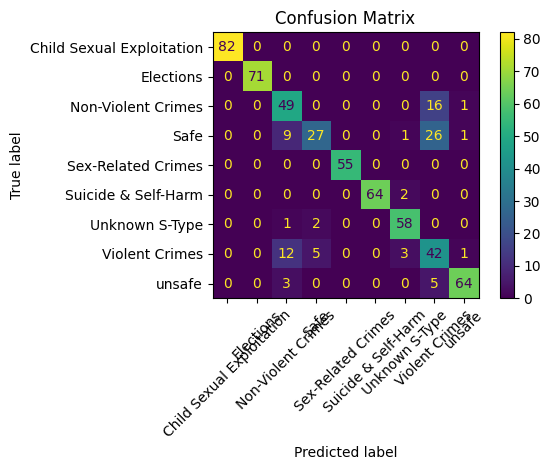

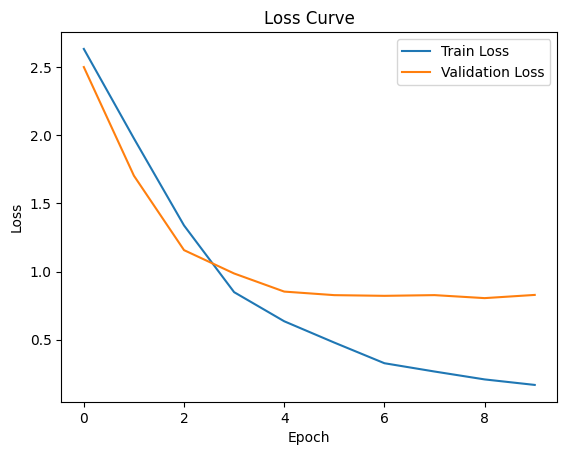

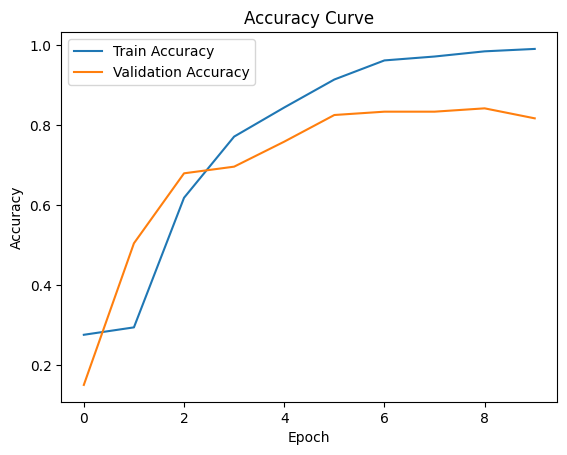

In [ ]:
# =====================
# Evaluation
# =====================
y_pred = np.argmax(model.predict(X_test_pad), axis=1)

f1 = f1_score(ytest, y_pred, average="weighted")
print("Weighted F1-score:", f1)

# =====================
# Confusion Matrix
# =====================
cm = confusion_matrix(ytest, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)
disp.plot(xticks_rotation=45)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# =====================
# Training Curves
# =====================
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.legend()
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()